In [ ]:
pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 28.3 MB/s eta 0:00:00


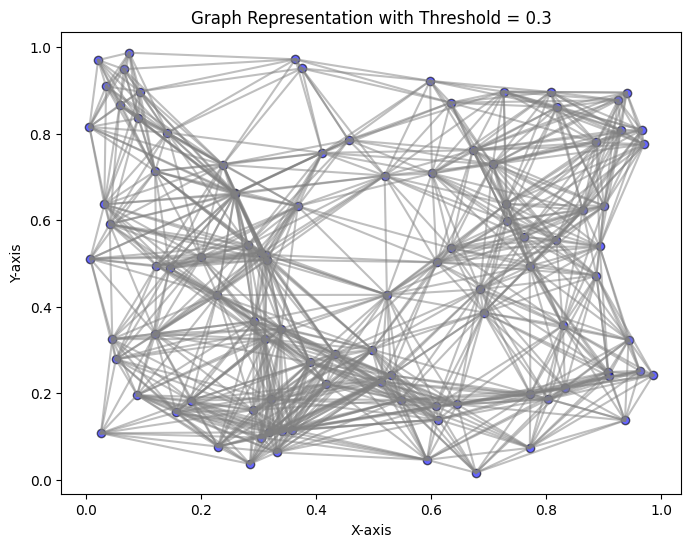

Number of connected components at threshold 0.3: 1


In [ ]:
# Step 1: Generate a synthetic 2D point cloud dataset again
np.random.seed(42)  # For reproducibility
points = np.random.rand(100, 2)  # 100 random points in 2D space

# Step 2: Compute pairwise distance matrix
dist_matrix = distance_matrix(points, points)

# Define a threshold for edge connections
threshold = 0.3

# Create a graph structure based on the threshold
edges = np.argwhere(dist_matrix < threshold)
edges = edges[edges[:, 0] < edges[:, 1]]  # Avoid duplicates

# Visualize the graph
plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], c='blue', alpha=0.6, edgecolor='k')
for edge in edges:
    p1, p2 = points[edge[0]], points[edge[1]]
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], c='gray', alpha=0.5)
plt.title(f"Graph Representation with Threshold = {threshold}")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

# Extract connected components for a basic topological analysis
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

# Create adjacency matrix
adj_matrix = (dist_matrix < threshold).astype(int)
graph = csr_matrix(adj_matrix)
n_components, labels = connected_components(csgraph=graph, directed=False)

# Display the number of connected components
print(f"Number of connected components at threshold {threshold}: {n_components}")

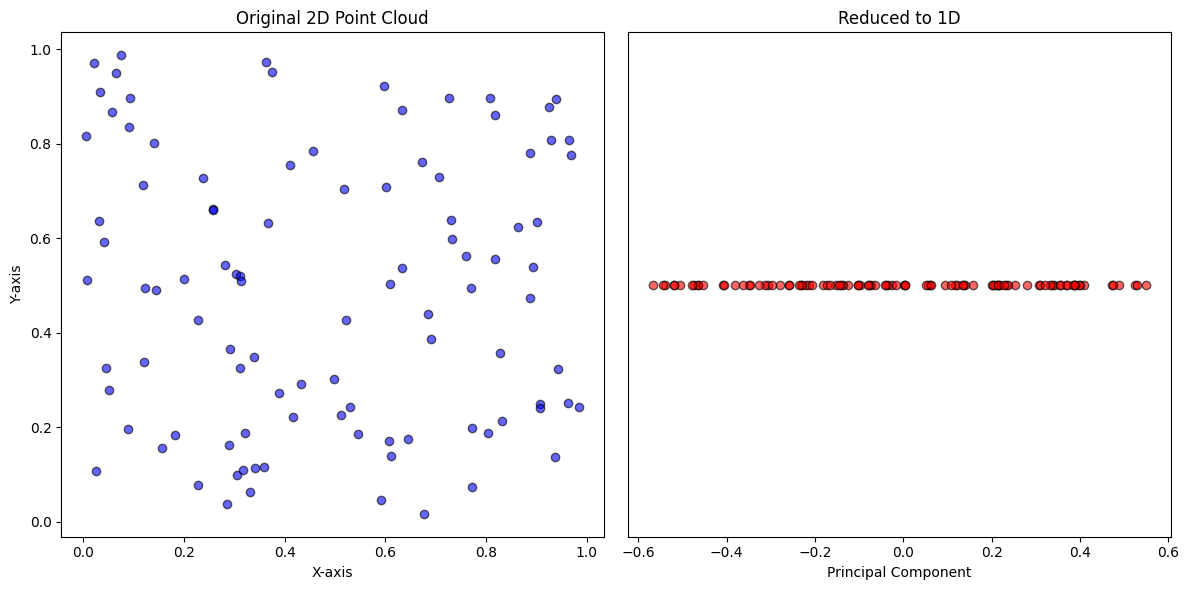

Explained Variance by the Principal Component: 0.54


In [ ]:
from sklearn.decomposition import PCA

# Step 1: Perform dimensionality reduction using PCA
pca = PCA(n_components=1)  # Reduce to 1 dimension
reduced_points = pca.fit_transform(points)

# Step 2: Visualize the reduced dimensional data along with the original
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(points[:, 0], points[:, 1], c='blue', alpha=0.6, edgecolor='k')
plt.title("Original 2D Point Cloud")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")

plt.subplot(1, 2, 2)
plt.scatter(reduced_points, np.zeros_like(reduced_points), c='red', alpha=0.6, edgecolor='k')
plt.title("Reduced to 1D")
plt.xlabel("Principal Component")
plt.yticks([])  # No Y-axis as it's a 1D representation

plt.tight_layout()
plt.show()

# Step 3: Analyze the retained variance to ensure the topology's structure is preserved
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance by the Principal Component: {explained_variance[0]:.2f}")

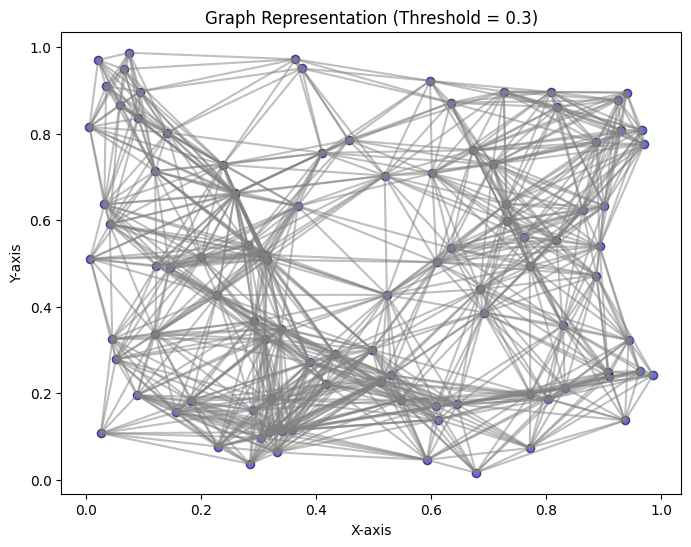

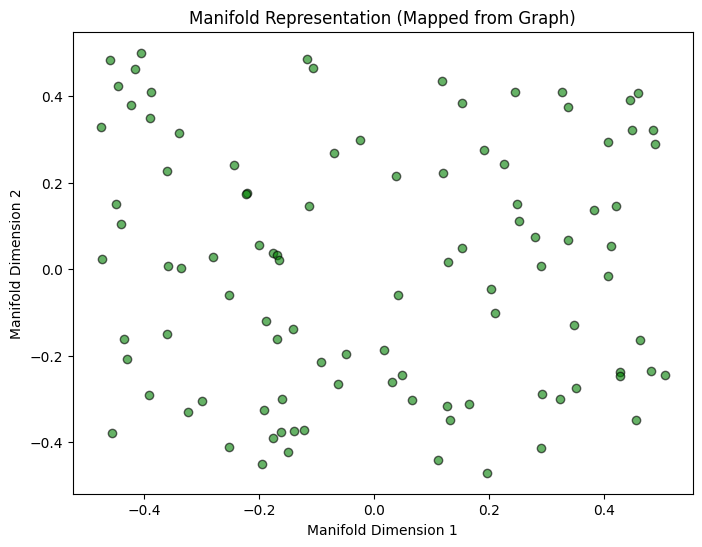

Transition from Graph to Manifold completed successfully.


In [ ]:
from sklearn.manifold import MDS

# Step 1: Create a graph structure based on proximity (using a threshold as before)
threshold = 0.3
edges = np.argwhere(dist_matrix < threshold)
edges = edges[edges[:, 0] < edges[:, 1]]  # Avoid duplicates

# Step 2: Visualize the graph (repeating for continuity)
plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], c='blue', alpha=0.6, edgecolor='k')
for edge in edges:
    p1, p2 = points[edge[0]], points[edge[1]]
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], c='gray', alpha=0.5)
plt.title(f"Graph Representation (Threshold = {threshold})")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

# Step 3: Transition to a manifold using MDS (Multidimensional Scaling)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
# Use the pairwise distances as input
manifold_points = mds.fit_transform(dist_matrix)

# Step 4: Visualize the manifold
plt.figure(figsize=(8, 6))
plt.scatter(manifold_points[:, 0], manifold_points[:, 1], c='green', alpha=0.6, edgecolor='k')
plt.title("Manifold Representation (Mapped from Graph)")
plt.xlabel("Manifold Dimension 1")
plt.ylabel("Manifold Dimension 2")
plt.show()

# Step 5: Compare original and manifold spaces qualitatively
print("Transition from Graph to Manifold completed successfully.")

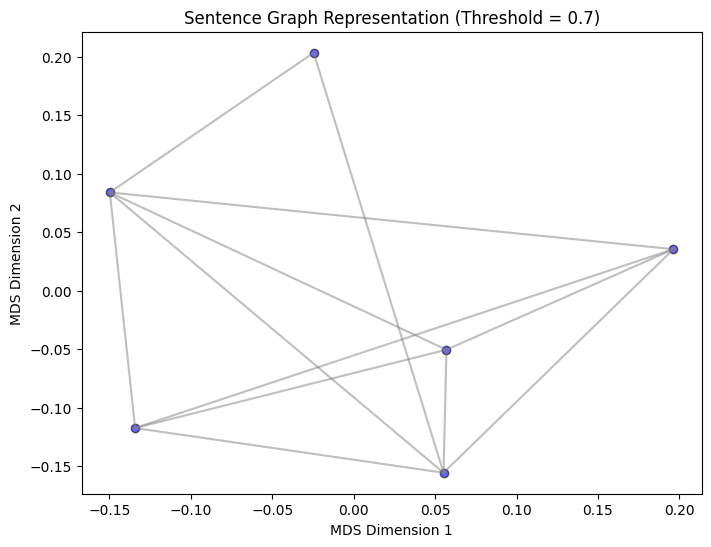

Similarity between original and reconstructed spaces: 0.73


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define a set of sentences (example data)
sentences = [
    "The cat sits on the mat.",
    "A dog is barking outside.",
    "The sun is shining brightly.",
    "Rain is falling in the city.",
    "The cat is purring happily.",
    "A dog and a cat are playing together."
]

# Step 2: Generate sentence embeddings using a placeholder approach
# (Replace with actual sentence embeddings from a model like Sentence Transformers if available)
np.random.seed(42)  # For consistent random embeddings
sentence_embeddings = np.random.rand(len(sentences), 50)  # 50-dimensional vectors

# Step 3: Compute a similarity matrix (cosine similarity)
similarity_matrix = cosine_similarity(sentence_embeddings)

# Step 4: Build a graph based on a similarity threshold
threshold = 0.7  # Define a similarity threshold
edges = np.argwhere(similarity_matrix > threshold)
edges = edges[edges[:, 0] < edges[:, 1]]  # Avoid duplicates

# Step 5: Visualize the sentence graph (reduced to 2D for clarity)
# Use MDS to reduce high-dimensional embeddings for visualization
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
reduced_points = mds.fit_transform(1 - similarity_matrix)  # Convert similarity to dissimilarity

plt.figure(figsize=(8, 6))
plt.scatter(reduced_points[:, 0], reduced_points[:, 1], c='blue', alpha=0.6, edgecolor='k')
for edge in edges:
    p1, p2 = reduced_points[edge[0]], reduced_points[edge[1]]
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], c='gray', alpha=0.5)
plt.title("Sentence Graph Representation (Threshold = 0.7)")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.show()

# Step 6: Transition to a manifold (via dimensional embedding of the graph)
manifold_embeddings = mds.fit_transform(1 - similarity_matrix)  # Same as above for simplicity

# Step 7: Test similarity between original embeddings and manifold embeddings
reconstructed_similarity = cosine_similarity(manifold_embeddings)
reconstruction_quality = np.corrcoef(similarity_matrix.flatten(), reconstructed_similarity.flatten())[0, 1]

print(f"Similarity between original and reconstructed spaces: {reconstruction_quality:.2f}")

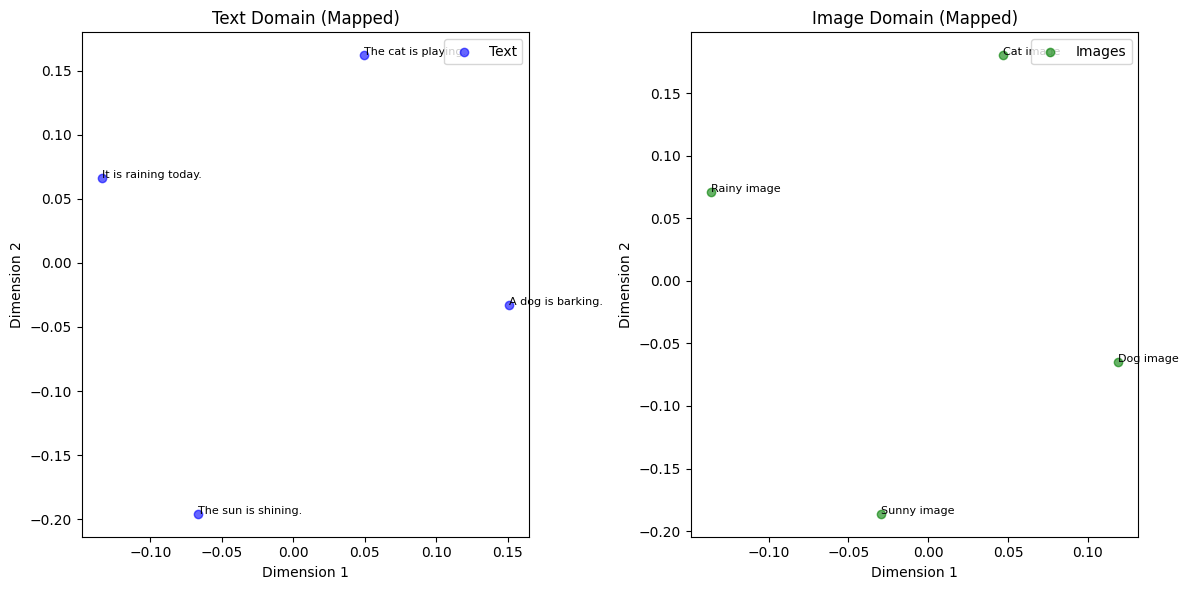

Cross-domain structural correlation: 0.95


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Define example data for two domains
# Domain A: Text (sentences with embeddings as placeholders)
text_sentences = [
    "The cat is playing.",
    "A dog is barking.",
    "The sun is shining.",
    "It is raining today."
]
# Placeholder embeddings for text (random for now; replace with actual embeddings)
np.random.seed(42)
text_embeddings = np.random.rand(len(text_sentences), 50)

# Domain B: Images (image features as placeholders)
image_labels = ["Cat image", "Dog image", "Sunny image", "Rainy image"]
# Placeholder embeddings for images (random for now; replace with actual features)
image_embeddings = np.random.rand(len(image_labels), 50)

# Step 2: Compute similarity matrices for each domain
text_similarity = cosine_similarity(text_embeddings)
image_similarity = cosine_similarity(image_embeddings)

# Step 3: Align the two domains using manifold alignment (via similarity preservation)
# Convert similarities to dissimilarities for MDS
text_dissimilarity = 1 - text_similarity
image_dissimilarity = 1 - image_similarity

# Reduce both to a shared 2D space using MDS for alignment
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
text_mapped = mds.fit_transform(text_dissimilarity)
image_mapped = mds.fit_transform(image_dissimilarity)

# Step 4: Visualize the mapping between domains
plt.figure(figsize=(12, 6))

# Text domain visualization
plt.subplot(1, 2, 1)
plt.scatter(text_mapped[:, 0], text_mapped[:, 1], c='blue', alpha=0.6, label="Text")
for i, sentence in enumerate(text_sentences):
    plt.text(text_mapped[i, 0], text_mapped[i, 1], sentence, fontsize=8)
plt.title("Text Domain (Mapped)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()

# Image domain visualization
plt.subplot(1, 2, 2)
plt.scatter(image_mapped[:, 0], image_mapped[:, 1], c='green', alpha=0.6, label="Images")
for i, label in enumerate(image_labels):
    plt.text(image_mapped[i, 0], image_mapped[i, 1], label, fontsize=8)
plt.title("Image Domain (Mapped)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()

plt.tight_layout()
plt.show()

# Step 5: Evaluate cross-domain similarity (correlation of structures)
text_flattened = text_similarity.flatten()
image_flattened = image_similarity.flatten()
cross_domain_correlation = np.corrcoef(text_flattened, image_flattened)[0, 1]

print(f"Cross-domain structural correlation: {cross_domain_correlation:.2f}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Domain-Specific Encoders
class TextEncoder(nn.Module):
    def __init__(self, input_dim, shared_dim):
        super(TextEncoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, shared_dim)
        )

    def forward(self, x):
        return self.fc(x)


class ImageEncoder(nn.Module):
    def __init__(self, input_dim, shared_dim):
        super(ImageEncoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, shared_dim)
        )

    def forward(self, x):
        return self.fc(x)


class SoundEncoder(nn.Module):
    def __init__(self, input_dim, shared_dim):
        super(SoundEncoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, shared_dim)
        )

    def forward(self, x):
        return self.fc(x)


# Shared Fusion Space
class FusionModel(nn.Module):
    def __init__(self, shared_dim):
        super(FusionModel, self).__init__()
        self.text_encoder = TextEncoder(input_dim=300, shared_dim=shared_dim)
        self.image_encoder = ImageEncoder(input_dim=2048, shared_dim=shared_dim)
        self.sound_encoder = SoundEncoder(input_dim=1024, shared_dim=shared_dim)

    def forward(self, text=None, image=None, sound=None):
        representations = []
        if text is not None:
            representations.append(self.text_encoder(text))
        if image is not None:
            representations.append(self.image_encoder(image))
        if sound is not None:
            representations.append(self.sound_encoder(sound))

        # Fusion through concatenation
        if len(representations) > 1:
            fused_representation = torch.cat(representations, dim=1)
        elif len(representations) == 1:
            fused_representation = representations[0]
        else:
            raise ValueError("At least one modality input should be provided")

        return fused_representation


# Training Loop
class FusionTrainer:
    def __init__(self, model, learning_rate=1e-3):
        self.model = model
        self.criterion = nn.MSELoss()  # Simplified loss for example
        self.optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    def train(self, data_loaders, labels, modality_combinations, epochs=10):
        for epoch in range(epochs):
            epoch_loss = 0.0
            for batch_index, data_batch in enumerate(zip(*data_loaders)):
                # Zero the parameter gradients
                self.optimizer.zero_grad()

                # Prepare inputs for each modality
                inputs = {}
                modality_names = ['text', 'image', 'sound']

                # Get the current modality combination
                current_combination = modality_combinations[batch_index % len(modality_combinations)]

                # Select the corresponding tensors for this batch
                for i, modality in enumerate(modality_names):
                    if modality in current_combination:
                        inputs[modality] = data_batch[i][0]

                # Forward pass through the FusionModel
                fused_representation = self.model(**inputs)

                # Create target tensor for simplicity
                target = torch.ones_like(fused_representation)
                loss = self.criterion(fused_representation, target)

                # Backward pass and optimize
                loss.backward()
                self.optimizer.step()

                epoch_loss += loss.item()

            print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")


# Example Usage
if __name__ == "__main__":
    # Example dimensions
    shared_dim = 128
    fusion_model = FusionModel(shared_dim=shared_dim)
    trainer = FusionTrainer(fusion_model)

    # Placeholder data
    text_data = torch.randn(100, 300)  # 100 text samples
    image_data = torch.randn(100, 2048)  # 100 image samples
    sound_data = torch.randn(100, 1024)  # 100 sound samples

    # Create TensorDatasets
    text_dataset = TensorDataset(text_data)
    image_dataset = TensorDataset(image_data)
    sound_dataset = TensorDataset(sound_data)

    # Create DataLoaders
    text_loader = DataLoader(text_dataset, batch_size=16, shuffle=True)
    image_loader = DataLoader(image_dataset, batch_size=16, shuffle=True)
    sound_loader = DataLoader(sound_dataset, batch_size=16, shuffle=True)

    # Create lists of data loaders and modality combinations
    data_loaders_list = [text_loader, image_loader, sound_loader]
    modality_combinations = [
        ('text',),
        ('image',),
        ('sound',),
        ('text', 'image'),
        ('text', 'sound'),
        ('image', 'sound'),
        ('text', 'image', 'sound')
    ]

    # Train the model with different modality combinations
    trainer.train(data_loaders_list, None, modality_combinations, epochs=5)

    print("Training complete. Fusion model is ready for use.")

Epoch 1/5, Loss: 6.9001
Epoch 2/5, Loss: 4.9428
Epoch 3/5, Loss: 3.4402
Epoch 4/5, Loss: 2.2781
Epoch 5/5, Loss: 1.5077
Training complete. Fusion model is ready for use.
